Nama : Yesha Faradina

NIM : 240401010072

Kelas : IF403

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


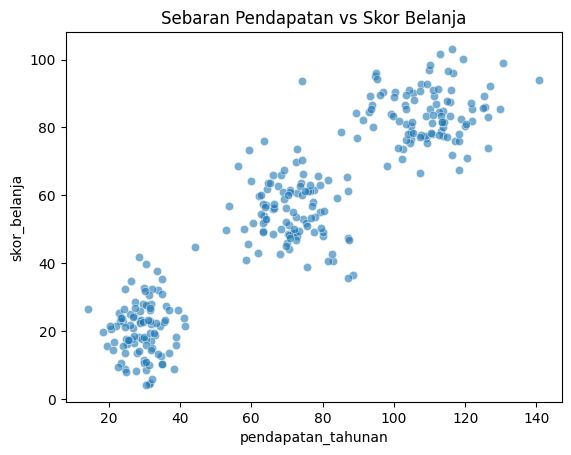

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

np.random.seed(42)
grp1  = np.random.normal([30, 20], [6, 8], (100, 2))    #hemat
grp2  = np.random.normal([70, 55], [8, 10], (100, 2))   #menengah
grp3  = np.random.normal([110, 85], [10, 8], (100, 2))  #boros
data  =  np.vstack([grp1, grp2, grp3])

df  = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia']    = np.random.randint(18, 65, len(df))
df['gender']  = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))


sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()


In [2]:
from os import X_OK
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))




Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


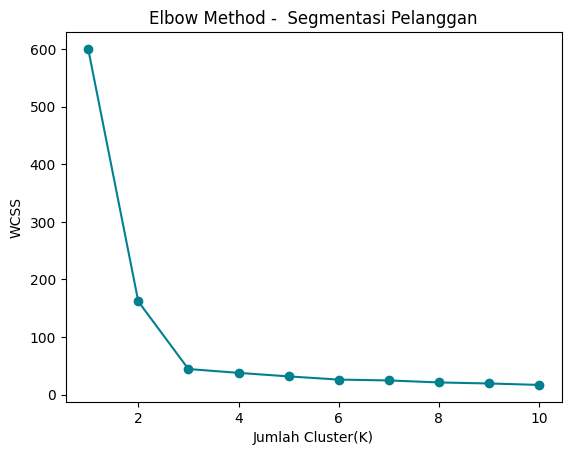

In [3]:
from sklearn.cluster import KMeans

wcss  = []
for k in range (1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster(K)'); plt.ylabel('WCSS')
plt.title('Elbow Method -  Segmentasi Pelanggan')
plt.show()

Ringkasan Grafik Metode Elbow
Kurva mulai mendatar pada K = 3, yang mengindikasikan jumlah klaster optimal. Nilai WCSS menurun secara signifikan dari K = 1 hingga K = 3, menunjukkan bahwa penambahan jumlah klaster secara substansial meningkatkan kualitas klasterisasi. Setelah melewati K = 3, penurunan nilai WCSS menjadi jauh lebih kecil, yang menandakan bahwa penambahan klaster lebih lanjut hanya memberikan peningkatan yang tidak signifikan.

Hasil ini sesuai dengan jumlah kelompok pelanggan yang diharapkan, mengingat dataset  sengaja dibuat dengan tiga segmen pelanggan yang berbeda:

Klaster 1: Konsumen dengan pendapatan tahunan minimal dan skor pengeluaran rendah

Klaster 2: Pelanggan dengan pendapatan tahunan dan peringkat pengeluaran tingkat menengah

Klaster 3: Klien dengan pendapatan tahunan dan peringkat pengeluaran tinggi

In [4]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir    : {model.inertia_}')
print(f'Silhouette   : {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir    : 44.5564179805733
Silhouette   : 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


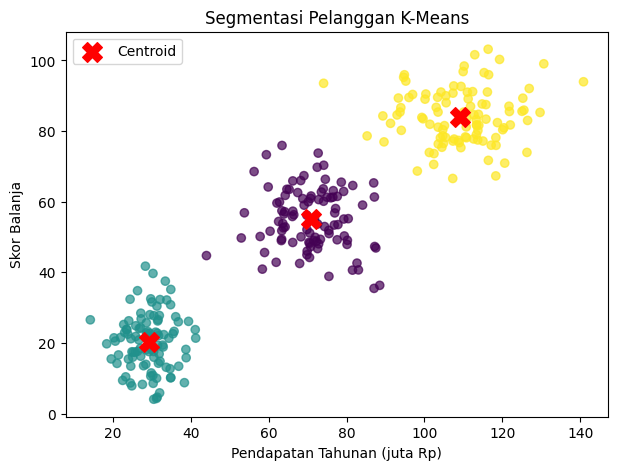

In [8]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Balanja')
plt.title('Segmentasi Pelanggan K-Means')
plt.legend()
plt.show()

A. Cluster 0 : Pelanggan mempunyai pendapatan yang rendah, dengan tingkat konsumsi yang juga rendah. Pelanggan biasanya berhati-hati dalam membeli dan dan peduli dangan harga.

B. Cluster 1 : Pelanggan memiliki pendapatan menengah/medium, tingkat konsumsi menengah. Pelanggan menunjukan pengeluaran yag seimbang dengan pemasukan yang didapat.

C. Cluster 2 : Pelanggan dengan pendapatan dan pengeluaran yang sama tingginya. Seringkali bersedia untuk merogoh harga yang tinggi pada produk ataupun jasa yang ditawarkan.

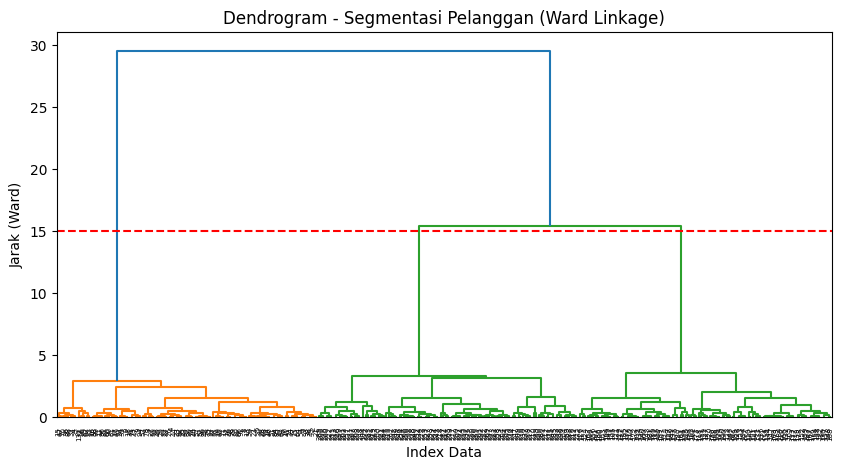

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram - Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Index Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--')
plt.show()

Dendrogram menunjukkan bahwa pemotongan horizontal pada jarak yang dipilih membagi data menjadi tiga klaster utama. Hal ini selaras dengan Metode Elbow, yang mengidentifikasi K = 3 sebagai nilai optimal, ditunjukan pada titik di mana kurva WCSS mulai mendatar. Kedua metode tersebut mengindikasikan bahwa dataset paling tepat direpresentasikan oleh tiga segmen pelanggan, sehingga mengonfirmasi bahwa K = 3 adalah pilihan yang tepat untuk segmentasi K-Means berdasarkan pendapatan dan skor pengeluaran.